# Verifying that `data/params/2d/thomas` really comes from a Thomas process

The parameter-estimation pipeline has been refactored several times recently
(`configs/params/cloud_generation.yaml` was split into per-process configs
`thomas_cloudgen.yaml` / `matern_cloudgen.yaml`, and `pipeline.py` now
supports `thomas`, `matern`, and `poisson`). Given the file-naming churn,
this notebook checks — from first principles, not just from the directory
name — that every cloud stored under `data/params/2d/thomas/` was actually
generated by `cloudforger.processes.thomas.ThomasProcess`.

Checks performed:

1. **Label consistency** — every record's `process` field and `params` schema.
2. **Schema exclusivity** — the recorded params match `ThomasProcess`'s
   constructor and would be *rejected* by `MaternHardCoreProcess` / `PoissonProcess`.
3. **Bit-exact replay (gold standard)** — generation is a pure function of
   `(params, region, seed)`. We rebuild `ThomasProcess(**params)` and replay
   `.sample(seed=seed)` for every stored cloud and diff the resulting points
   against what's on disk. If this matches, the data on disk was produced by
   *this* `ThomasProcess` implementation with the recorded seed — not just
   labeled that way.
4. **Statistical clustering signature** — an independent, code-free sanity
   check: Thomas processes cluster (excess of very small nearest-neighbour
   distances vs. a Poisson process of the same intensity), whereas Matérn
   hard-core processes forbid points closer than `hardcore_radius`. We check
   the empirical signature looks like clustering, not exclusion.
5. **Cross-file consistency** — `diagrams.pkl`, `betti.pkl`, `features.pkl`,
   `images.pkl` (and their `adversarial_*` counterparts) are checked against
   `clouds.pkl` for matching `process`, `seeds`, and record counts, to catch
   any stage that might have silently consumed data from a different run.

In [1]:
import pickle
import sys
import warnings
from pathlib import Path

import numpy as np
import yaml
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "src" / "cloudforger").exists():
    # allow running the notebook from notebooks/ or from the project root
    PROJECT_ROOT = PROJECT_ROOT.parent if (PROJECT_ROOT.parent / "src" / "cloudforger").exists() else PROJECT_ROOT
SRC = PROJECT_ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

DATA_DIR = PROJECT_ROOT / "data" / "params" / "2d" / "thomas"
assert DATA_DIR.exists(), f"Expected data directory not found: {DATA_DIR}"

from cloudforger.processes.thomas import ThomasProcess
from cloudforger.processes.matern import MaternHardCoreProcess
from cloudforger.processes.poisson import PoissonProcess
from cloudforger.core.region import Box

print("Project root:", PROJECT_ROOT)
print("Data dir:    ", DATA_DIR)

Project root: /Users/qp252676/Desktop/point-process-tda
Data dir:     /Users/qp252676/Desktop/point-process-tda/data/params/2d/thomas


In [2]:
def load_pickle(path):
    with open(path, "rb") as f:
        return pickle.load(f)

clouds = load_pickle(DATA_DIR / "clouds.pkl")
adversarial_clouds = load_pickle(DATA_DIR / "adversarial_clouds.pkl")
manifest = yaml.safe_load((DATA_DIR / "cloud_generation_manifest.yaml").read_text())

print(f"train/test clouds:  {len(clouds)}")
print(f"adversarial clouds: {len(adversarial_clouds)}")
print(f"manifest config process: {manifest['config']['process']!r}")
clouds[0]

train/test clouds:  4960
adversarial clouds: 872
manifest config process: 'thomas'


{'points': array([[3.05298293e-02, 3.79054589e-03],
        [2.28726098e-02, 6.07171904e-04],
        [6.15921015e-01, 7.35586888e-01],
        [6.20011264e-01, 7.32074269e-01],
        [5.42062351e-01, 9.57150571e-01],
        [5.45615264e-01, 9.62487284e-01],
        [5.46312587e-01, 9.49309350e-01],
        [5.43482174e-01, 9.47019590e-01],
        [8.67927419e-01, 2.33745356e-02],
        [8.70263509e-01, 2.28010397e-02],
        [7.36677735e-01, 1.59004429e-01],
        [8.78955006e-01, 5.48276934e-01],
        [8.78511127e-01, 5.40192025e-01],
        [8.70999981e-01, 5.36112068e-01],
        [8.80219493e-01, 5.48068234e-01],
        [2.90878893e-01, 4.14222886e-01],
        [1.38176688e-02, 1.02852638e-01],
        [5.88711752e-03, 1.12359697e-01],
        [6.08749810e-01, 3.80956504e-01]]),
 'params': {'parent_intensity': 10.000000000000002,
  'mean_offspring': 2.0,
  'cluster_scale': 0.005000000000000002},
 'process': 'thomas',
 'seed': 0,
 'n_points': 19,
 'dimension': 2,
 'r

## Check 1 — label consistency

Every stored record carries its own `process` name and `params` dict
(written by `cloud_to_record` at generation time, not derived from the
directory path). If any record disagrees with the directory name or has an
inconsistent parameter schema, that's direct evidence of a naming mix-up.

In [3]:
def check_label_consistency(records, split_name):
    processes = {r["process"] for r in records}
    schemas = {frozenset(r["params"].keys()) for r in records}
    dims = {r["dimension"] for r in records}

    print(f"[{split_name}] n_records={len(records)}")
    print(f"[{split_name}] distinct 'process' labels: {processes}")
    print(f"[{split_name}] distinct param-key schemas: {schemas}")
    print(f"[{split_name}] distinct dimensions: {dims}")

    ok = processes == {"thomas"} and len(schemas) == 1
    print(f"[{split_name}] -> {'PASS' if ok else 'FAIL'}: single 'thomas' label with a uniform param schema\n")
    return ok

label_ok_tt = check_label_consistency(clouds, "clouds.pkl (train/test)")
label_ok_adv = check_label_consistency(adversarial_clouds, "adversarial_clouds.pkl")

[clouds.pkl (train/test)] n_records=4960
[clouds.pkl (train/test)] distinct 'process' labels: {'thomas'}
[clouds.pkl (train/test)] distinct param-key schemas: {frozenset({'cluster_scale', 'parent_intensity', 'mean_offspring'})}
[clouds.pkl (train/test)] distinct dimensions: {2}
[clouds.pkl (train/test)] -> PASS: single 'thomas' label with a uniform param schema

[adversarial_clouds.pkl] n_records=872
[adversarial_clouds.pkl] distinct 'process' labels: {'thomas'}
[adversarial_clouds.pkl] distinct param-key schemas: {frozenset({'cluster_scale', 'parent_intensity', 'mean_offspring'})}
[adversarial_clouds.pkl] distinct dimensions: {2}
[adversarial_clouds.pkl] -> PASS: single 'thomas' label with a uniform param schema



## Check 2 — schema exclusivity

`ThomasProcess.__init__` takes `{parent_intensity, mean_offspring,
cluster_scale}`. `MaternHardCoreProcess` takes `{parent_intensity,
hardcore_radius}` and `PoissonProcess` takes yet another signature. We
confirm the recorded params match Thomas's signature exactly and would
raise a `TypeError` if fed into the other two constructors — i.e. this data
could not plausibly be mislabeled Matérn or Poisson output.

In [4]:
import inspect

def ctor_params(cls):
    return set(inspect.signature(cls.__init__).parameters) - {"self"}

thomas_schema = ctor_params(ThomasProcess)
matern_schema = ctor_params(MaternHardCoreProcess)
poisson_schema = ctor_params(PoissonProcess)

print("ThomasProcess params: ", thomas_schema)
print("MaternHardCoreProcess params:", matern_schema)
print("PoissonProcess params:", poisson_schema)

recorded_schema = frozenset(clouds[0]["params"].keys())
print("\nRecorded schema:", set(recorded_schema))

matches_thomas = recorded_schema == thomas_schema
try:
    MaternHardCoreProcess(**clouds[0]["params"])
    rejected_by_matern = False
except TypeError:
    rejected_by_matern = True
try:
    PoissonProcess(**clouds[0]["params"])
    rejected_by_poisson = False
except TypeError:
    rejected_by_poisson = True

print(f"\nMatches ThomasProcess signature exactly: {matches_thomas}")
print(f"Rejected by MaternHardCoreProcess(**params): {rejected_by_matern}")
print(f"Rejected by PoissonProcess(**params):        {rejected_by_poisson}")

schema_ok = matches_thomas and rejected_by_matern and rejected_by_poisson
print(f"\n-> {'PASS' if schema_ok else 'FAIL'}")

ThomasProcess params:  {'cluster_scale', 'parent_intensity', 'mean_offspring'}
MaternHardCoreProcess params: {'parent_intensity', 'hardcore_radius'}
PoissonProcess params: {'intensity'}

Recorded schema: {'cluster_scale', 'parent_intensity', 'mean_offspring'}

Matches ThomasProcess signature exactly: True
Rejected by MaternHardCoreProcess(**params): True
Rejected by PoissonProcess(**params):        True

-> PASS


## Check 3 — bit-exact replay (gold standard)

`ThomasProcess.sample(n, region, seed)` seeds a fresh `np.random.default_rng(seed)`
and is otherwise a pure function of `(parent_intensity, mean_offspring,
cluster_scale, region, seed)`. That means we can independently regenerate
every stored cloud from its recorded metadata and diff it against the
points on disk. A match is about as strong a guarantee as possible that the
data really was produced by *this* Thomas implementation.

In [5]:
def record_region(record):
    reg = record.get("region")
    if reg is None:
        return Box(low=np.zeros(record["dimension"]), high=np.ones(record["dimension"]))
    return Box(low=np.asarray(reg["low"], dtype=float), high=np.asarray(reg["high"], dtype=float))


def replay_and_diff(record):
    process = ThomasProcess(**record["params"])
    region = record_region(record)
    replayed = process.sample(n=0, region=region, seed=record["seed"])
    stored = np.asarray(record["points"])
    if replayed.points.shape != stored.shape:
        return False, f"shape mismatch: replayed {replayed.points.shape} vs stored {stored.shape}"
    if not np.array_equal(replayed.points, stored):
        max_abs_diff = np.max(np.abs(replayed.points - stored)) if replayed.points.size else float("nan")
        return False, f"values differ, max abs diff = {max_abs_diff}"
    return True, None


def replay_split(records, split_name):
    mismatches = []
    for i, r in enumerate(records):
        ok, reason = replay_and_diff(r)
        if not ok:
            mismatches.append((i, reason))
        if (i + 1) % 500 == 0 or i + 1 == len(records):
            print(f"\r[{split_name}] replayed {i + 1}/{len(records)}", end="", flush=True)
    print()
    if mismatches:
        print(f"[{split_name}] -> FAIL: {len(mismatches)}/{len(records)} clouds do NOT reproduce.")
        for i, reason in mismatches[:10]:
            print(f"    record {i}: {reason}")
    else:
        print(f"[{split_name}] -> PASS: all {len(records)} clouds reproduce bit-exactly from "
              f"ThomasProcess(**params).sample(seed=seed).")
    return mismatches

mismatches_tt = replay_split(clouds, "clouds.pkl (train/test)")

[clouds.pkl (train/test)] replayed 500/4960

[clouds.pkl (train/test)] replayed 1000/4960

[clouds.pkl (train/test)] replayed 1500/4960

[clouds.pkl (train/test)] replayed 2000/4960

[clouds.pkl (train/test)] replayed 2500/4960

...

[clouds.pkl (train/test)] replayed 3500/4960

[clouds.pkl (train/test)] replayed 4000/4960

[clouds.pkl (train/test)] replayed 4500/4960

[clouds.pkl (train/test)] replayed 4960/4960


[clouds.pkl (train/test)] -> PASS: all 4960 clouds reproduce bit-exactly from ThomasProcess(**params).sample(seed=seed).


In [6]:
mismatches_adv = replay_split(adversarial_clouds, "adversarial_clouds.pkl")

[adversarial_clouds.pkl] replayed 500/872

[adversarial_clouds.pkl] replayed 872/872


[adversarial_clouds.pkl] -> PASS: all 872 clouds reproduce bit-exactly from ThomasProcess(**params).sample(seed=seed).


## Check 4 — statistical clustering signature (code-independent)

Even without trusting any code path, a Thomas (Neyman-Scott) process has a
distinctive *clustering* signature: many pairs of points sit much closer
together than a Poisson process of the same intensity would produce, because
offspring huddle around parents. A Matérn Type-II hard-core process is the
opposite — no two points can be closer than `hardcore_radius`, so the
nearest-neighbour distribution has a hard cutoff near zero.

We plot a few example clouds and the empirical nearest-neighbour distance
distribution against a CSR (Poisson) baseline of matched intensity.

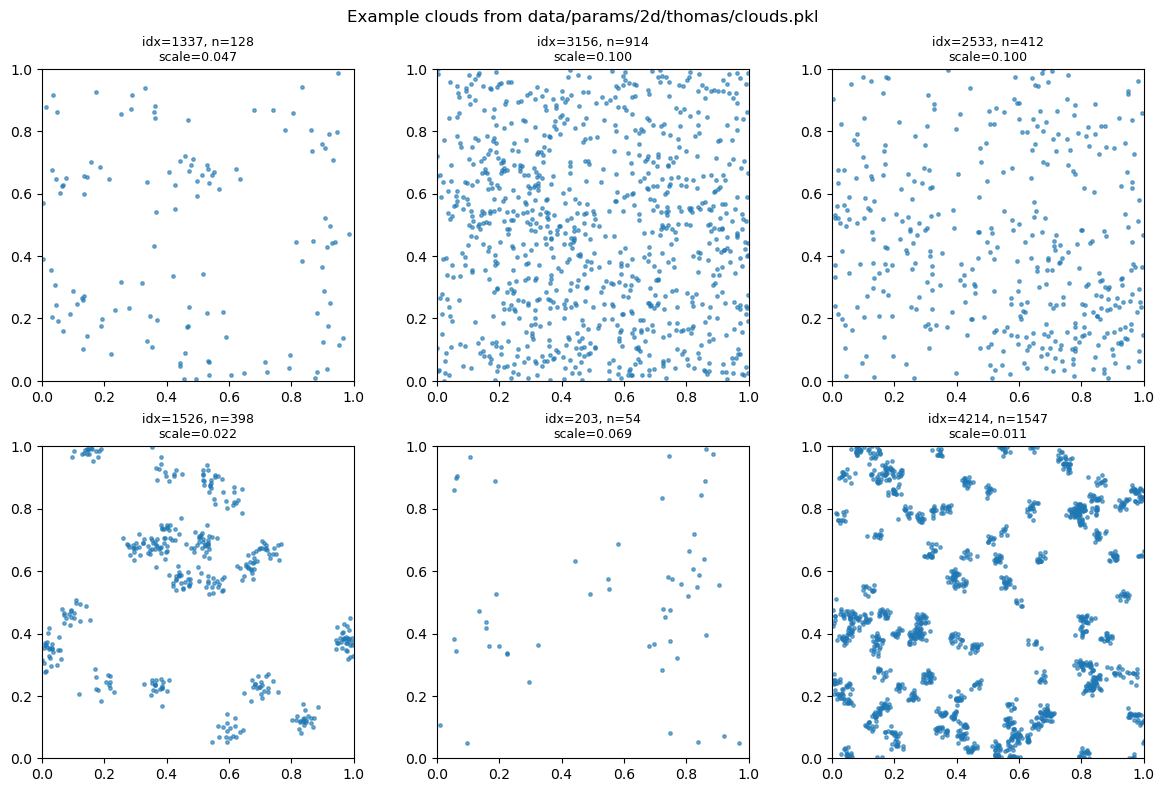

In [7]:
from scipy.spatial import cKDTree

rng = np.random.default_rng(0)
sample_idx = rng.choice(len(clouds), size=6, replace=False)

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
for ax, idx in zip(axes.ravel(), sample_idx):
    r = clouds[idx]
    pts = r["points"]
    ax.scatter(pts[:, 0], pts[:, 1], s=6, alpha=0.6)
    ax.set_title(f"idx={idx}, n={r['n_points']}\nscale={r['params']['cluster_scale']:.3f}", fontsize=9)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.set_aspect("equal")
fig.suptitle("Example clouds from data/params/2d/thomas/clouds.pkl")
fig.tight_layout()
plt.show()

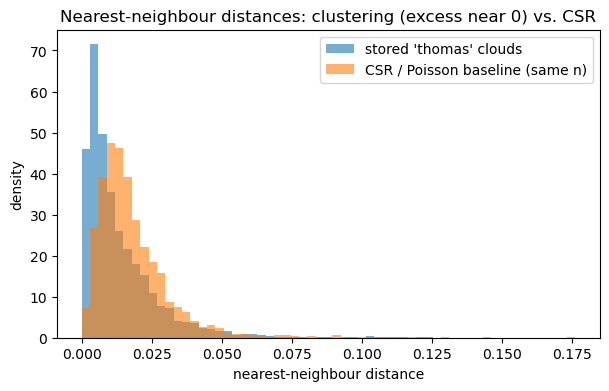

Fraction of NN distances < 10% of Poisson-baseline median:
  stored 'thomas' clouds: 0.043
  Poisson baseline:       0.006
-> PASS: stored clouds show a clear excess of very close pairs relative to CSR, i.e. a clustering (not hard-core) signature.


In [8]:
def nn_distances(points):
    if len(points) < 2:
        return np.array([])
    tree = cKDTree(points)
    d, _ = tree.query(points, k=2)
    return d[:, 1]

# Pool nearest-neighbour distances across a batch of stored (Thomas) clouds.
batch = [clouds[i] for i in sample_idx]
thomas_nn = np.concatenate([nn_distances(r["points"]) for r in batch])

# Poisson baseline with the same point counts, for comparison.
poisson_nn = []
for r in batch:
    n = r["n_points"]
    pts = rng.uniform(0, 1, size=(n, 2))
    poisson_nn.append(nn_distances(pts))
poisson_nn = np.concatenate(poisson_nn) if poisson_nn else np.array([])

fig, ax = plt.subplots(figsize=(7, 4))
bins = np.linspace(0, max(thomas_nn.max(), poisson_nn.max(), 1e-6), 60)
ax.hist(thomas_nn, bins=bins, alpha=0.6, density=True, label="stored 'thomas' clouds")
ax.hist(poisson_nn, bins=bins, alpha=0.6, density=True, label="CSR / Poisson baseline (same n)")
ax.set_xlabel("nearest-neighbour distance")
ax.set_ylabel("density")
ax.legend()
ax.set_title("Nearest-neighbour distances: clustering (excess near 0) vs. CSR")
plt.show()

frac_thomas_tiny = np.mean(thomas_nn < np.median(poisson_nn) * 0.1)
frac_poisson_tiny = np.mean(poisson_nn < np.median(poisson_nn) * 0.1)
print(f"Fraction of NN distances < 10% of Poisson-baseline median:")
print(f"  stored 'thomas' clouds: {frac_thomas_tiny:.3f}")
print(f"  Poisson baseline:       {frac_poisson_tiny:.3f}")
cluster_signature_ok = frac_thomas_tiny > 3 * max(frac_poisson_tiny, 1e-9)
print(f"-> {'PASS' if cluster_signature_ok else 'FAIL'}: stored clouds show a clear excess of very "
      f"close pairs relative to CSR, i.e. a clustering (not hard-core) signature.")

## Check 5 — cross-file consistency

The pipeline stages (`compute_pairwise`, `compute_diagrams`,
`vectorize_diagrams`, `compute_betti`) each independently record their own
`process` label and per-record `seeds`/`params`. If a later stage had ever
picked up clouds from a different run (e.g. a stale `matern` output copied
into the wrong folder), the `process` label, seed ordering, or record count
would disagree with `clouds.pkl`. `images.pkl` / `adversarial_images.pkl`
are the largest files (hundreds of MB) — loading them takes the longest
here.

In [9]:
def check_downstream_file(path, key_process, key_seeds, ref_seeds, split_name):
    if not path.exists():
        print(f"[{split_name}] {path.name}: MISSING, skipping")
        return None
    data = load_pickle(path)
    process = data.get(key_process)
    seeds = list(data.get(key_seeds, []))
    n_ok = len(seeds) == len(ref_seeds)
    process_ok = process == "thomas"
    seeds_ok = seeds == ref_seeds
    status = "PASS" if (n_ok and process_ok and seeds_ok) else "FAIL"
    print(f"[{split_name}] {path.name}: process={process!r}, n={len(seeds)} "
          f"(expected {len(ref_seeds)}), seeds match clouds.pkl order: {seeds_ok} -> {status}")
    return n_ok and process_ok and seeds_ok


ref_seeds_tt = [r["seed"] for r in clouds]
ref_seeds_adv = [r["seed"] for r in adversarial_clouds]

downstream_results = {}
for fname, split_name, ref_seeds in [
    ("diagrams.pkl", "train/test", ref_seeds_tt),
    ("betti.pkl", "train/test", ref_seeds_tt),
    ("features.pkl", "train/test", ref_seeds_tt),
    ("images.pkl", "train/test", ref_seeds_tt),
    ("adversarial_diagrams.pkl", "adversarial", ref_seeds_adv),
    ("adversarial_betti.pkl", "adversarial", ref_seeds_adv),
    ("adversarial_features.pkl", "adversarial", ref_seeds_adv),
    ("adversarial_images.pkl", "adversarial", ref_seeds_adv),
]:
    downstream_results[fname] = check_downstream_file(
        DATA_DIR / fname, "process", "seeds", ref_seeds, split_name
    )

[train/test] diagrams.pkl: process='thomas', n=4960 (expected 4960), seeds match clouds.pkl order: True -> PASS
[train/test] betti.pkl: process='thomas', n=4960 (expected 4960), seeds match clouds.pkl order: True -> PASS
[train/test] features.pkl: process='thomas', n=4960 (expected 4960), seeds match clouds.pkl order: True -> PASS
[train/test] images.pkl: process='thomas', n=4960 (expected 4960), seeds match clouds.pkl order: True -> PASS


[adversarial] adversarial_diagrams.pkl: process='thomas', n=872 (expected 872), seeds match clouds.pkl order: True -> PASS
[adversarial] adversarial_betti.pkl: process='thomas', n=872 (expected 872), seeds match clouds.pkl order: True -> PASS
[adversarial] adversarial_features.pkl: process='thomas', n=872 (expected 872), seeds match clouds.pkl order: True -> PASS
[adversarial] adversarial_images.pkl: process='thomas', n=872 (expected 872), seeds match clouds.pkl order: True -> PASS


## Summary

In [10]:
summary = {
    "1. label consistency (train/test)": label_ok_tt,
    "1. label consistency (adversarial)": label_ok_adv,
    "2. schema exclusive to ThomasProcess": schema_ok,
    "3. bit-exact replay (train/test)": len(mismatches_tt) == 0,
    "3. bit-exact replay (adversarial)": len(mismatches_adv) == 0,
    "4. clustering signature (not hard-core)": cluster_signature_ok,
    **{f"5. downstream consistency: {k}": v for k, v in downstream_results.items() if v is not None},
}

width = max(len(k) for k in summary)
for k, v in summary.items():
    print(f"{k.ljust(width)} : {'PASS' if v else 'FAIL'}")

all_pass = all(summary.values())
print("\n" + ("ALL CHECKS PASSED — data/params/2d/thomas is genuinely Thomas-process output."
              if all_pass else
              "SOME CHECKS FAILED — see details above; the 'thomas' directory may be contaminated."))

1. label consistency (train/test)                   : PASS
1. label consistency (adversarial)                  : PASS
2. schema exclusive to ThomasProcess                : PASS
3. bit-exact replay (train/test)                    : PASS
3. bit-exact replay (adversarial)                   : PASS
4. clustering signature (not hard-core)             : PASS
5. downstream consistency: diagrams.pkl             : PASS
5. downstream consistency: betti.pkl                : PASS
5. downstream consistency: features.pkl             : PASS
5. downstream consistency: images.pkl               : PASS
5. downstream consistency: adversarial_diagrams.pkl : PASS
5. downstream consistency: adversarial_betti.pkl    : PASS
5. downstream consistency: adversarial_features.pkl : PASS
5. downstream consistency: adversarial_images.pkl   : PASS

ALL CHECKS PASSED — data/params/2d/thomas is genuinely Thomas-process output.
